# Incomplete-Fix Case Set — Descriptive Statistics & Visualizations

This notebook analyzes **51 incomplete-fix cases (52 rows, including sibling
CASE-03B)**: real-world CVE lineages where an original fix did not fully
remediate a vulnerability, a bypass was later found, and (in nearly every
case) a complete fix eventually closed the gap. Regressions (a fix
introducing a new vulnerability) and reintroductions (a fix's protection
later weakened/removed) are explicitly excluded by construction — every row
was screened against those definitions before being included.

**What this notebook produces:**
1. A 13-subtype / 6-parent-group taxonomy of *how* each fix was incomplete,
   assigned by reading each case's root-cause text.
2. ~20 charts covering subtype distribution, CWE classes, CVSS severity,
   time-to-bypass-discovery, ecosystem/language splits, lineage length,
   discoverer type, and cross-tabulations between all of the above.
3. Exported CSVs/TXT summaries for downstream use (including by the
   companion correlation/bias/ML-feasibility notebook).

**Inputs expected in the same directory:** `incomplete_fixes_2.csv`
(edit `CSV_PATH` below if yours is named differently).

## 0. Setup

In [2]:
import os
import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use("Agg")  # switch to default backend automatically in Jupyter; harmless otherwise
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print(matplotlib.get_backend())

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["axes.titleweight"] = "bold"

CSV_PATH = "incomplete_fixes_2.csv"     # <-- edit if your filename differs
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(OUTDIR, name)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print("saved:", path)

module://matplotlib_inline.backend_inline


## 1. Subtype taxonomy

13 fine-grained subtypes rolling up into 6 parent groups. This taxonomy was
built by reading every case's `root_cause_category`, `bypass_mechanism_root_cause`,
and `classification_note` text — each case gets exactly **one** primary
subtype label (its most defining trait), even where a case shows secondary
traits.

In [3]:
"""
Shared incomplete-fix subtype taxonomy for the 52-row / 51-case dataset
(CASE-01 .. CASE-51, plus sibling CASE-03B).

Every case gets exactly ONE primary subtype, assigned by reading its
root_cause_category + bypass_mechanism_root_cause + classification_note
text. Cases 1-18 retain the classification from the first-batch analysis;
cases 19-51 are newly classified here using the same methodology.
"""

# ---------------------------------------------------------------------------
# Parent groups (6) -- coarse-grained families the fine subtypes roll up into
# ---------------------------------------------------------------------------
PARENT_GROUP_ORDER = [
    "Structural Duplication",
    "Logic / Invariant Error",
    "Call-Chain / Scope",
    "Dual-Operation Symmetry",
    "Trust-Boundary / Delegation Gap",
    "Process / Supply-Chain Failure",
]

PARENT_GROUP_DEFINITIONS = {
    "Structural Duplication":
        "The fix needed to be applied at N structurally similar sites "
        "(files / code trees / call sites / list members / branches) and "
        "was only applied at M < N of them.",
    "Logic / Invariant Error":
        "A guard/check exists and runs, but its condition, threshold, "
        "type width, or the quantity it protects does not actually match "
        "the real attack/overflow condition -- not a coverage gap.",
    "Call-Chain / Scope":
        "The exploitable defect lives at a different point in the call "
        "chain (an upstream caller/validator, downstream consumer, or a "
        "producer/consumer counterpart) than where the patch landed.",
    "Dual-Operation Symmetry":
        "Two mirror-image operations exist (open/close, alloc/fill, "
        "read/write, create/finalize); the fix hardens one side and "
        "leaves its structural mirror untouched.",
    "Trust-Boundary / Delegation Gap":
        "The fix never examined WHO/WHAT could invoke the protected path, "
        "or silently delegated a security-relevant invariant to code "
        "(often a third-party library) that was never itself audited.",
    "Process / Supply-Chain Failure":
        "The gap is not a code-logic defect at all -- it is a packaging, "
        "release, or backport-assertion failure (a fix was claimed to be "
        "shipped/applied but was not).",
}

PARENT_COLORS = {
    "Structural Duplication":          "#2E5EAA",
    "Logic / Invariant Error":         "#4E9B4E",
    "Call-Chain / Scope":              "#E07B39",
    "Dual-Operation Symmetry":         "#B4436C",
    "Trust-Boundary / Delegation Gap": "#8A5A83",
    "Process / Supply-Chain Failure":  "#9A9A3D",
}

# ---------------------------------------------------------------------------
# Fine-grained subtypes (13) -- definitions
# ---------------------------------------------------------------------------
SUBTYPE_DEFINITIONS = {
    "Parallel implementation miss":
        "The same logic is duplicated across multiple files, code trees, "
        "binaries, or lookup-path implementations (e.g. SDL2 vs SDL3, "
        "generic vs SIMD, Web vs Component server); the fix is applied to "
        "only a subset of the duplicates.",
    "Security logic implemented but not applied":
        "A reusable protective primitive (helper function, macro, wrapper) "
        "was correctly written and correctly used at most call sites, but "
        "was never wired into one additional site that needed it.",
    "Field/parameter-family miss":
        "The fix enumerates a family of fields/parameters/members/option-"
        "spellings/reference-holder-classes to protect but omits one "
        "member of that family.",
    "Backport/distro re-derivation miss":
        "A downstream distro, LTS branch, or older codebase's fix had to "
        "be manually re-implemented (not cherry-picked verbatim) against "
        "differently-structured code, and the re-derivation introduced a "
        "gap the upstream, verbatim version does not have.",
    "Scope-of-audit miss":
        "The original fix was produced by an audit (manual, grep-based, or "
        "reproducer-driven) that covered the exact reported call site / "
        "branch / function but never widened to structurally similar "
        "sibling call sites, branches, or functions.",
    "Wrong invariant / off-by-construction":
        "A guard/bound/algorithm was added and IS reached, but its "
        "condition, threshold, sentinel value, or design does not actually "
        "match the real overflow/bypass condition (miscalibration or "
        "algorithmic edge case, not a coverage gap).",
    "Platform/environment-dependent assumption":
        "The fix's correctness silently depends on a platform-specific "
        "property (integer width, architecture, build configuration) that "
        "does not hold on every supported platform.",
    "Incidental invariant loss (refactor side-effect)":
        "A refactor that correctly fixes the targeted defect incidentally "
        "removes an unrelated side effect that other code silently relied "
        "on, opening a new (different-class) gap in the same commit.",
    "Upstream/downstream caller miss":
        "The exploitable defect actually lives in a different function of "
        "the call chain (an upstream validator/caller, a downstream "
        "consumer, or the producer/reader counterpart of a build/read "
        "pair) than the function that was patched.",
    "Symmetric/dual-operation miss":
        "Two mirror-image operations exist (open/close, alloc/fill, "
        "read/write, create/finalize, '('/')'); the fix hardens one side "
        "and leaves its structural mirror untouched.",
    "Threat-model too narrow (who/what unconsidered)":
        "The fix correctly restricts WHICH resource/path may be used, but "
        "never asks WHO may trigger the operation or WHAT the operation "
        "itself can do as a side effect -- the exploited primitive sat "
        "entirely outside the original threat model.",
    "Delegated/unaudited external-dependency miss":
        "A security invariant (e.g. constant-time behaviour) is silently "
        "delegated to a third-party library or component whose internals "
        "were never audited and are outside the fixer's control.",
    "Packaging/backport assertion failure":
        "There is no source-code defect distinct from the original "
        "vulnerability; an advisory/package asserted a fix was shipped "
        "when the shipped binary still contained the original, unpatched "
        "code.",
}

# subtype -> parent group
SUBTYPE_PARENT = {
    "Parallel implementation miss":                        "Structural Duplication",
    "Security logic implemented but not applied":           "Structural Duplication",
    "Field/parameter-family miss":                          "Structural Duplication",
    "Backport/distro re-derivation miss":                   "Structural Duplication",
    "Scope-of-audit miss":                                  "Structural Duplication",
    "Wrong invariant / off-by-construction":                "Logic / Invariant Error",
    "Platform/environment-dependent assumption":            "Logic / Invariant Error",
    "Incidental invariant loss (refactor side-effect)":     "Logic / Invariant Error",
    "Upstream/downstream caller miss":                      "Call-Chain / Scope",
    "Symmetric/dual-operation miss":                        "Dual-Operation Symmetry",
    "Threat-model too narrow (who/what unconsidered)":      "Trust-Boundary / Delegation Gap",
    "Delegated/unaudited external-dependency miss":         "Trust-Boundary / Delegation Gap",
    "Packaging/backport assertion failure":                 "Process / Supply-Chain Failure",
}

# ---------------------------------------------------------------------------
# case_id -> fine subtype   (52 rows: CASE-01..CASE-51 + sibling CASE-03B)
# ---------------------------------------------------------------------------
SUBTYPE_MAP = {
    "CASE-01": "Symmetric/dual-operation miss",
    "CASE-02": "Symmetric/dual-operation miss",
    "CASE-03": "Scope-of-audit miss",
    "CASE-03B": "Security logic implemented but not applied",
    "CASE-04": "Parallel implementation miss",
    "CASE-05": "Upstream/downstream caller miss",
    "CASE-06": "Parallel implementation miss",
    "CASE-07": "Wrong invariant / off-by-construction",
    "CASE-08": "Field/parameter-family miss",
    "CASE-09": "Symmetric/dual-operation miss",
    "CASE-10": "Parallel implementation miss",
    "CASE-11": "Upstream/downstream caller miss",
    "CASE-12": "Security logic implemented but not applied",
    "CASE-13": "Wrong invariant / off-by-construction",
    "CASE-14": "Wrong invariant / off-by-construction",
    "CASE-15": "Upstream/downstream caller miss",
    "CASE-16": "Security logic implemented but not applied",
    "CASE-17": "Parallel implementation miss",
    "CASE-18": "Parallel implementation miss",
    "CASE-19": "Threat-model too narrow (who/what unconsidered)",
    "CASE-20": "Backport/distro re-derivation miss",
    "CASE-21": "Wrong invariant / off-by-construction",
    "CASE-22": "Upstream/downstream caller miss",
    "CASE-23": "Backport/distro re-derivation miss",
    "CASE-24": "Wrong invariant / off-by-construction",
    "CASE-25": "Wrong invariant / off-by-construction",
    "CASE-26": "Symmetric/dual-operation miss",
    "CASE-27": "Backport/distro re-derivation miss",
    "CASE-28": "Scope-of-audit miss",
    "CASE-29": "Scope-of-audit miss",
    "CASE-30": "Platform/environment-dependent assumption",
    "CASE-31": "Field/parameter-family miss",
    "CASE-32": "Field/parameter-family miss",
    "CASE-33": "Field/parameter-family miss",
    "CASE-34": "Wrong invariant / off-by-construction",
    "CASE-35": "Scope-of-audit miss",
    "CASE-36": "Wrong invariant / off-by-construction",
    "CASE-37": "Upstream/downstream caller miss",
    "CASE-38": "Backport/distro re-derivation miss",
    "CASE-39": "Field/parameter-family miss",
    "CASE-40": "Scope-of-audit miss",
    "CASE-41": "Upstream/downstream caller miss",
    "CASE-42": "Upstream/downstream caller miss",
    "CASE-43": "Wrong invariant / off-by-construction",
    "CASE-44": "Scope-of-audit miss",
    "CASE-45": "Field/parameter-family miss",
    "CASE-46": "Delegated/unaudited external-dependency miss",
    "CASE-47": "Delegated/unaudited external-dependency miss",
    "CASE-48": "Packaging/backport assertion failure",
    "CASE-49": "Security logic implemented but not applied",
    "CASE-50": "Incidental invariant loss (refactor side-effect)",
    "CASE-51": "Field/parameter-family miss",
}


def get_parent(case_id):
    return SUBTYPE_PARENT[SUBTYPE_MAP[case_id]]


def classify_row(case_id):
    sub = SUBTYPE_MAP[case_id]
    return sub, SUBTYPE_PARENT[sub], SUBTYPE_DEFINITIONS[sub]

## 2. Free-text field parsers

Heuristic, best-effort parsers for the analyst-prose CSV fields (CWE tokens, CVSS scores, time gaps, ecosystem, language, discoverer type). All are approximations of free text and are documented as such — treat single-case conclusions drawn from these fields with appropriate caution; they are most reliable in aggregate.

In [4]:
"""
Free-text field parsers shared by both notebooks. Every parser is
best-effort/heuristic (the source fields are analyst prose, not
structured data) and documented as such in the notebooks.
"""
import re
import numpy as np

# --------------------------------------------------------------------
# CWE / CVSS
# --------------------------------------------------------------------
def extract_cwe_ids(text):
    if not isinstance(text, str):
        return []
    return sorted(set(re.findall(r"CWE-(\d+)", text)))


def extract_cvss_scores(text):
    """All plausible 0.0-10.0 CVSS base scores mentioned in a free-text field."""
    if not isinstance(text, str):
        return []
    out = []
    for m in re.findall(r"\b(\d{1,2}\.\d)\b", text):
        v = float(m)
        if 0.0 <= v <= 10.0:
            out.append(v)
    return out


def first_cvss(text):
    s = extract_cvss_scores(text)
    return s[0] if s else np.nan


def max_cvss(text):
    s = extract_cvss_scores(text)
    return max(s) if s else np.nan


def extract_severity_word(text):
    if not isinstance(text, str):
        return None
    for w in ["CRITICAL", "HIGH", "MEDIUM", "LOW", "NONE"]:
        if w in text.upper():
            return w.title()
    return None


# --------------------------------------------------------------------
# num_distinct_cve_ids_in_lineage  ("2", "3 (shared lineage w/ CASE-03B)")
# --------------------------------------------------------------------
def parse_num_cves(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"(\d+)", text)
    return int(m.group(1)) if m else np.nan


# --------------------------------------------------------------------
# Time gap between original fix and bypass discovery
# --------------------------------------------------------------------
GAP_ORDER = ["< 1 week", "1-4 weeks", "1-6 months", "6-24 months", "2+ years", "Unknown"]

def bucket_gap(text):
    if not isinstance(text, str) or not text.strip():
        return "Unknown"
    t = text.lower()
    if any(p in t for p in ["essentially immediate", "same release", "same commit", "days apart"]):
        pass  # fall through to day/week parsing below for precision
    m_days = re.search(r"(\d+)\s*day", t)
    m_weeks = re.search(r"(\d+)\s*week", t)
    m_months = re.search(r"~?\u2248?(\d+(?:\.\d+)?)\s*\+?\s*month", t)
    m_years = re.search(r"~?\u2248?(\d+(?:\.\d+)?)\s*\+?\s*year", t)
    if m_years:
        y = float(m_years.group(1))
        return "6-24 months" if y < 2 else "2+ years"
    if m_months:
        mo = float(m_months.group(1))
        if mo < 1:
            return "1-4 weeks"
        elif mo <= 6:
            return "1-6 months"
        else:
            return "6-24 months"
    if m_weeks:
        w = int(m_weeks.group(1))
        return "1-4 weeks" if w <= 4 else "1-6 months"
    if m_days:
        d = int(m_days.group(1))
        return "< 1 week" if d < 7 else "1-4 weeks"
    if "immediate" in t or "same release" in t or "same commit" in t or "days apart" in t:
        return "< 1 week"
    return "Unknown"


def gap_days_numeric(text):
    """Approximate numeric day count for correlation/regression use. NaN if unparseable."""
    if not isinstance(text, str) or not text.strip():
        return np.nan
    t = text.lower()
    m_years = re.search(r"~?\u2248?(\d+(?:\.\d+)?)\s*\+?\s*year", t)
    if m_years:
        return float(m_years.group(1)) * 365.25
    m_months = re.search(r"~?\u2248?(\d+(?:\.\d+)?)\s*\+?\s*month", t)
    if m_months:
        return float(m_months.group(1)) * 30.44
    m_weeks = re.search(r"(\d+)\s*week", t)
    if m_weeks:
        return float(m_weeks.group(1)) * 7
    m_days = re.search(r"(\d+)\s*day", t)
    if m_days:
        return float(m_days.group(1))
    if "immediate" in t or "same release" in t or "same commit" in t:
        return 1.0
    return np.nan


# --------------------------------------------------------------------
# Ecosystem / domain classification (heuristic, from product_component +
# source_file_path(s) + affected_language)
# --------------------------------------------------------------------
_ECOSYSTEM_RULES = [
    ("OS Kernel",                 [r"\blinux kernel\b", r"\bkernel\b", r"^net/", r"drivers/", r"fs/smb", r"net/sched", r"net/core"]),
    ("Hypervisor / Virtualization",[r"\bxen\b", r"\bqemu\b", r"hypervisor", r"virtio"]),
    ("Windowing / Display System", [r"x\.org", r"xserver", r"xwayland", r"\bxkb\b"]),
    ("Network Daemon / Protocol Server", [r"dovecot", r"openssh", r"ssh-agent", r"\bhttp server\b", r"apache http", r"ldap", r"389 directory", r"unbound", r"dns resolver", r"netfilter", r"ebtables", r"nftables"]),
    ("Browser / Web Client",       [r"brave browser", r"firefox", r"chrom"]),
    ("Language Runtime / Interpreter", [r"\bphp\b", r"redis", r"tensorflow"]),
    ("Media / Codec Library",      [r"libsndfile", r"gstreamer", r"wav demuxer", r"furnace", r"chiptune"]),
    ("Parsing / Data-format Library", [r"libexpat", r"editorconfig", r"pillow", r"tiff", r"bento4", r"mp4", r"binutils", r"bfd", r"rpm package"]),
    ("Archive / Compression Tool", [r"gnome-autoar", r"file-roller", r"zstandard", r"\bzstd\b"]),
    ("Embedded / IoT Stack",       [r"netx duo", r"threadx", r"azure rtos"]),
    ("Wireless / WPA Security",    [r"hostapd", r"wpa_supplicant"]),
    ("System Utility / Init",      [r"systemd", r"iputils", r"\bping\b", r"sysstat", r"conemu"]),
    ("VM / Container Management",  [r"multipass", r"dnf5daemon"]),
    ("HTTP Client Library",        [r"cpp-httplib"]),
    ("Backup / Ops Tool",          [r"percona xtrabackup"]),
    ("Remote Access Client",       [r"freerdp", r"\brdp\b"]),
    ("Print/Document Interpreter", [r"ghostscript", r"ghostpdl", r"postscript"]),
    ("GUI / Desktop Utility Library", [r"tinyfiledialogs", r"native-dialog"]),
]

def classify_ecosystem(product_component, source_paths):
    blob = f"{product_component or ''} {source_paths or ''}".lower()
    for label, patterns in _ECOSYSTEM_RULES:
        for pat in patterns:
            if re.search(pat, blob):
                return label
    return "Other / Unclassified"


_ECOSYSTEM_TIER_RULES = [
    ("OS / Kernel-space", ["OS Kernel", "Hypervisor / Virtualization", "Windowing / Display System"]),
    ("Network-facing Service", ["Network Daemon / Protocol Server", "Browser / Web Client",
                                 "Wireless / WPA Security", "Remote Access Client"]),
    ("Embedded / IoT", ["Embedded / IoT Stack"]),
    ("Userspace Library / Tool", ["Parsing / Data-format Library", "Media / Codec Library",
                                  "Archive / Compression Tool", "System Utility / Init",
                                  "VM / Container Management", "HTTP Client Library",
                                  "Backup / Ops Tool", "Language Runtime / Interpreter",
                                  "Print/Document Interpreter", "GUI / Desktop Utility Library"]),
]

def classify_ecosystem_tier(fine_ecosystem):
    for tier, members in _ECOSYSTEM_TIER_RULES:
        if fine_ecosystem in members:
            return tier
    return "Other / Unclassified"


# --------------------------------------------------------------------
# Language normalisation
# --------------------------------------------------------------------
def normalize_language(text):
    if not isinstance(text, str) or not text.strip():
        return "Unknown"
    t = text.strip()
    tl = t.lower()
    if tl.startswith("c++"):
        return "C++"
    if tl.startswith("c ") or tl == "c" or tl.startswith("c/"):
        return "C"
    if "python" in tl:
        return "Python"
    if "php" in tl:
        return "PHP"
    if "shell" in tl or "plist" in tl:
        return "Shell/Config (non-memory-safety)"
    if "c#" in tl:
        return "C#"
    return t if len(t) < 20 else "Other/Mixed"


# --------------------------------------------------------------------
# Discoverer-type heuristic
# --------------------------------------------------------------------
def parse_year(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"(19|20)\d{2}", text)
    return int(m.group(0)) if m else np.nan


def is_unresolved(classification_note):
    if not isinstance(classification_note, str):
        return False
    return "UNRESOLVED" in classification_note.upper()


def lineage_stage_count(row):
    n = 2
    if isinstance(row.get("third_fix_attempt_cve_id"), str) and row.get("third_fix_attempt_cve_id").strip():
        n += 1
    if isinstance(row.get("fourth_fix_attempt_cve_id"), str) and row.get("fourth_fix_attempt_cve_id").strip():
        n += 1
    return n


def classify_discoverer(text):
    if not isinstance(text, str) or not text.strip():
        return "Unknown / Not named"
    t = text.lower()
    if any(k in t for k in ["syzbot", "fuzz", "kernel test robot", "ci ", "ubsan", "asan", "static analysis", "coverity", "unused 'ret' variable", "flagging the"]):
        return "Automated (fuzzing/CI/static-analysis)"
    if any(k in t for k in ["red hat", "canonical", "cna", "vendor", "eclipse", "google", "microsoft", "amazon", "cisco", "innora security", "zero day initiative", "trendai", "yeswehack", "talos"]):
        return "Vendor / Security Team / Coordinated Research Group"
    if any(k in t for k in ["not individually named", "not named", "unnamed"]):
        return "Unknown / Not named"
    return "Named Independent Researcher"

## 3. Load & enrich the dataset

In [5]:
df = pd.read_csv(CSV_PATH)
assert df["case_id"].is_unique, "case_id should be unique per row"

missing = set(df["case_id"]) - set(SUBTYPE_MAP)
if missing:
    raise SystemExit(f"Unclassified case_id(s) -- add to SUBTYPE_MAP in the taxonomy cell: {missing}")

df["subtype"] = df["case_id"].map(SUBTYPE_MAP)
df["parent_group"] = df["subtype"].map(SUBTYPE_PARENT)
df["subtype_definition"] = df["subtype"].map(SUBTYPE_DEFINITIONS)

df["orig_cwe_list"] = df["original_cve_cwe"].map(extract_cwe_ids)
df["incomplete_cwe_list"] = df["incomplete_fix_cve_cwe"].map(extract_cwe_ids)
df["all_cwe_list"] = df.apply(lambda r: sorted(set(r["orig_cwe_list"]) | set(r["incomplete_cwe_list"])), axis=1)
df["primary_cwe"] = df["all_cwe_list"].map(lambda l: ("CWE-" + l[0]) if l else "Unspecified")

df["orig_cvss"] = df["original_cve_cvss"].map(first_cvss)
df["incomplete_cvss"] = df["incomplete_fix_cve_cvss"].map(first_cvss)
df["cvss_delta"] = df["incomplete_cvss"] - df["orig_cvss"]
df["orig_severity_word"] = df["original_cve_cvss"].map(extract_severity_word)
df["incomplete_severity_word"] = df["incomplete_fix_cve_cvss"].map(extract_severity_word)

df["ecosystem"] = df.apply(lambda r: classify_ecosystem(r["product_component"], r["source_file_path(s)"]), axis=1)
df["ecosystem_tier"] = df["ecosystem"].map(classify_ecosystem_tier)
df["language_norm"] = df["affected_language"].map(normalize_language)

df["gap_bucket"] = df["gap_between_original_fix_and_bypass_discovery"].map(bucket_gap)
df["gap_days"] = df["gap_between_original_fix_and_bypass_discovery"].map(gap_days_numeric)

df["n_cves_in_lineage"] = df["num_distinct_cve_ids_in_lineage"].map(parse_num_cves)
df["lineage_stage_count"] = df.apply(lineage_stage_count, axis=1)

df["discoverer_type"] = df["discoverer_of_incomplete_fix"].map(classify_discoverer)
df["orig_fix_year"] = df["original_fix_date"].map(parse_year)
df["bypass_year"] = df["discovery_date_of_bypass"].map(parse_year)
df["is_unresolved"] = df["classification_note"].map(is_unresolved)

print(f"{len(df)} rows / {df.case_id.nunique()} unique case_ids loaded and enriched.")
df[["case_id","product_component","subtype","parent_group"]].head(10)

52 rows / 52 unique case_ids loaded and enriched.


,case_id,product_component,subtype,parent_group
0,CASE-01,editorconfig-core-c (libeditorconfig) — Editor...,Symmetric/dual-operation miss,Dual-Operation Symmetry
1,CASE-02,"Dovecot IMAP/POP3 server — imap-login process,...",Symmetric/dual-operation miss,Dual-Operation Symmetry
2,CASE-03,libexpat — streaming XML parser embedded in Py...,Scope-of-audit miss,Structural Duplication
3,CASE-03B,libexpat — streaming XML parser embedded in Py...,Security logic implemented but not applied,Structural Duplication
4,CASE-04,libsndfile — cross-platform C audio file libra...,Parallel implementation miss,Structural Duplication
5,CASE-05,X.Org X Server (xserver) and Xwayland — XKB (X...,Upstream/downstream caller miss,Call-Chain / Scope
6,CASE-06,Canonical Multipass (macOS) — VM management to...,Parallel implementation miss,Structural Duplication
7,CASE-07,GStreamer gst-plugins-good — WAV demuxer (used...,Wrong invariant / off-by-construction,Logic / Invariant Error
8,CASE-08,389 Directory Server (389-ds-base) — LDAP dire...,Field/parameter-family miss,Structural Duplication
9,CASE-09,QEMU — open source machine emulator/virtualize...,Symmetric/dual-operation miss,Dual-Operation Symmetry


## 4. Subtype classification table

One row per case: the subtype call plus the definition it was matched against. Export this alongside the CSV so a reviewer can audit/override any individual call.

In [6]:
classification_table = df[["case_id","product_component","original_cve_id","incomplete_fix_cve_id",
                            "subtype","parent_group","subtype_definition"]].copy()
classification_table.to_csv(os.path.join(OUTDIR, "..", "subtype_classification.csv"), index=False)
classification_table

,case_id,product_component,original_cve_id,incomplete_fix_cve_id,subtype,parent_group,subtype_definition
0,CASE-01,editorconfig-core-c (libeditorconfig) — Editor...,CVE-2023-0341,CVE-2026-40489,Symmetric/dual-operation miss,Dual-Operation Symmetry,"Two mirror-image operations exist (open/close,..."
1,CASE-02,"Dovecot IMAP/POP3 server — imap-login process,...",CVE-2026-27857,CVE-2026-42006,Symmetric/dual-operation miss,Dual-Operation Symmetry,"Two mirror-image operations exist (open/close,..."
2,CASE-03,libexpat — streaming XML parser embedded in Py...,CVE-2026-50219,CVE-2026-56412,Scope-of-audit miss,Structural Duplication,The original fix was produced by an audit (man...
3,CASE-03B,libexpat — streaming XML parser embedded in Py...,CVE-2026-50219,CVE-2026-56131,Security logic implemented but not applied,Structural Duplication,A reusable protective primitive (helper functi...
4,CASE-04,libsndfile — cross-platform C audio file libra...,CVE-2022-33065,CVE-2026-37555,Parallel implementation miss,Structural Duplication,The same logic is duplicated across multiple f...
5,CASE-05,X.Org X Server (xserver) and Xwayland — XKB (X...,CVE-2025-26597,CVE-2026-50258,Upstream/downstream caller miss,Call-Chain / Scope,The exploitable defect actually lives in a dif...
6,CASE-06,Canonical Multipass (macOS) — VM management to...,CVE-2025-5199,CVE-2026-49237,Parallel implementation miss,Structural Duplication,The same logic is duplicated across multiple f...
7,CASE-07,GStreamer gst-plugins-good — WAV demuxer (used...,CVE-2024-47778 (GHSL-2024-258),CVE-2026-1940,Wrong invariant / off-by-construction,Logic / Invariant Error,A guard/bound/algorithm was added and IS reach...
8,CASE-08,389 Directory Server (389-ds-base) — LDAP dire...,CVE-2025-14905,CVE-2026-11884,Field/parameter-family miss,Structural Duplication,The fix enumerates a family of fields/paramete...
9,CASE-09,QEMU — open source machine emulator/virtualize...,CVE-2024-7730,CVE-2026-3195,Symmetric/dual-operation miss,Dual-Operation Symmetry,"Two mirror-image operations exist (open/close,..."


## 5. Subtype distribution

saved: figures\01_subtype_distribution.png


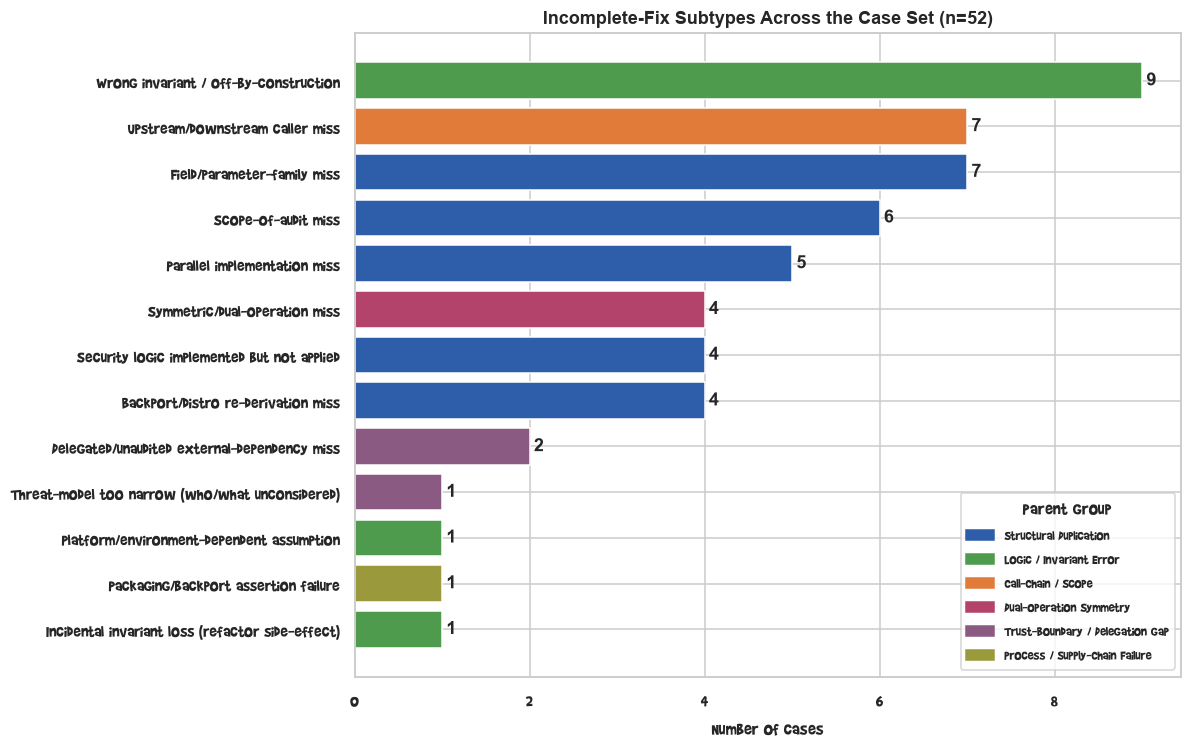

In [7]:
subtype_counts = df["subtype"].value_counts()
colors = [PARENT_COLORS[SUBTYPE_PARENT[s]] for s in subtype_counts.index]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(subtype_counts.index[::-1], subtype_counts.values[::-1], color=colors[::-1])
ax.set_xlabel("Number of cases")
ax.set_title(f"Incomplete-Fix Subtypes Across the Case Set (n={len(df)})")
for bar, v in zip(bars, subtype_counts.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, str(v), va="center", fontweight="bold")
handles = [plt.Rectangle((0,0),1,1, color=PARENT_COLORS[g]) for g in PARENT_GROUP_ORDER]
ax.legend(handles, PARENT_GROUP_ORDER, title="Parent group", loc="lower right", fontsize=9)
savefig(fig, "01_subtype_distribution.png")
plt.show()

## 6. Parent-group distribution

saved: figures\02_parent_group_distribution.png


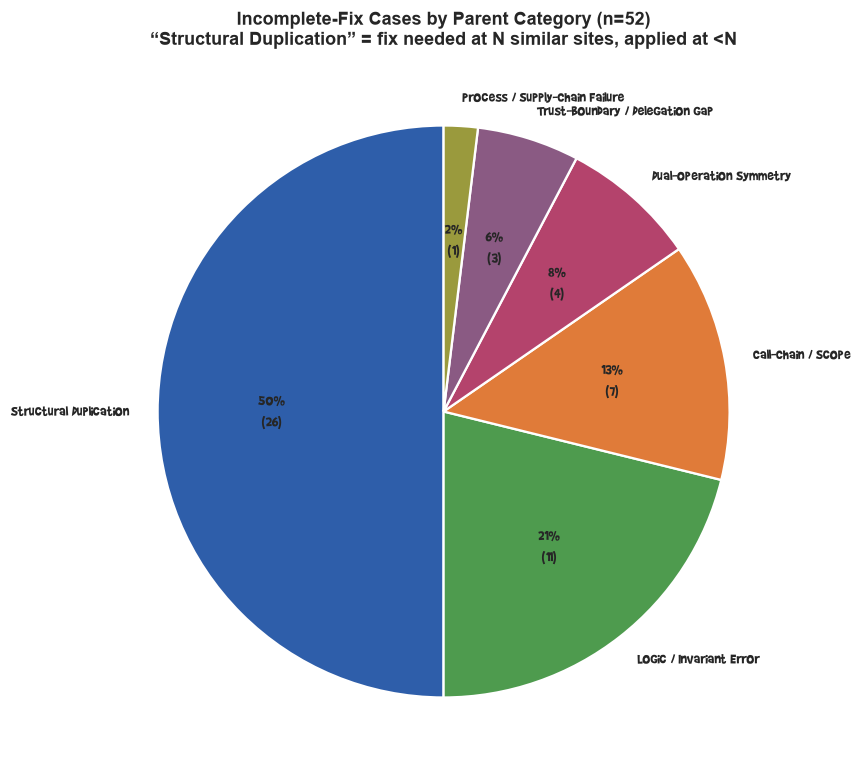

parent_group
Structural Duplication             26
Logic / Invariant Error            11
Call-Chain / Scope                  7
Dual-Operation Symmetry             4
Trust-Boundary / Delegation Gap     3
Process / Supply-Chain Failure      1
Name: count, dtype: int64

Structural Duplication share: 50.0%


In [8]:
parent_counts = df["parent_group"].value_counts().reindex(PARENT_GROUP_ORDER).dropna()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    parent_counts.values, labels=parent_counts.index,
    colors=[PARENT_COLORS[g] for g in parent_counts.index],
    autopct=lambda p: f"{p:.0f}%\n({round(p*parent_counts.sum()/100)})",
    startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5), textprops=dict(fontsize=10)
)
ax.set_title(f"Incomplete-Fix Cases by Parent Category (n={len(df)})\n"
             "\u201cStructural Duplication\u201d = fix needed at N similar sites, applied at <N")
savefig(fig, "02_parent_group_distribution.png")
plt.show()
print(parent_counts)
print(f"\nStructural Duplication share: {100*parent_counts['Structural Duplication']/len(df):.1f}%")

## 7. Subtype counts nested within parent group (donut)

saved: figures\03_parent_subtype_donut.png


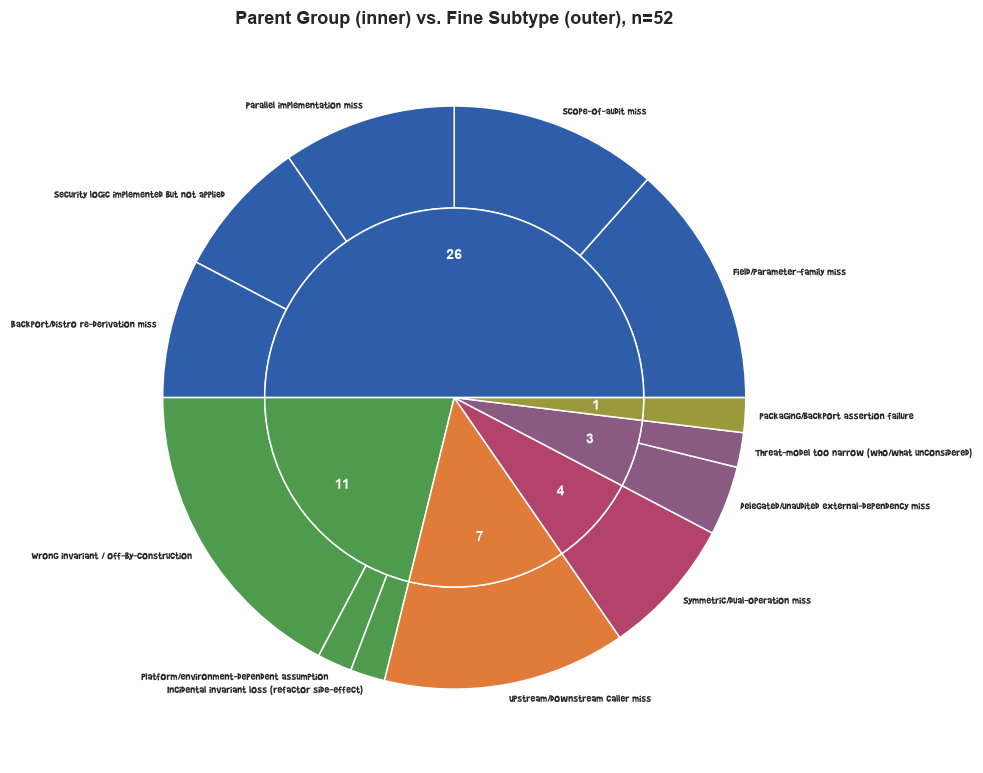

In [9]:
fig, ax = plt.subplots(figsize=(9, 9))
inner_vals = parent_counts.values
inner_colors = [PARENT_COLORS[g] for g in parent_counts.index]

outer_labels, outer_vals, outer_colors = [], [], []
for g in parent_counts.index:
    sub = df.loc[df.parent_group == g, "subtype"].value_counts()
    for s, v in sub.items():
        outer_labels.append(s)
        outer_vals.append(v)
        outer_colors.append(PARENT_COLORS[g])

ax.pie(outer_vals, radius=1.0, colors=outer_colors, labels=outer_labels,
       labeldistance=1.05, textprops=dict(fontsize=7.5),
       wedgeprops=dict(width=0.35, edgecolor="white"))
ax.pie(inner_vals, radius=0.65, colors=inner_colors,
       autopct=lambda p: f"{round(p*sum(inner_vals)/100)}", pctdistance=0.75,
       wedgeprops=dict(width=0.65, edgecolor="white"), textprops=dict(fontsize=9, color="white", fontweight="bold"))
ax.set_title(f"Parent Group (inner) vs. Fine Subtype (outer), n={len(df)}")
savefig(fig, "03_parent_subtype_donut.png")
plt.show()

## 8. CWE frequency across the dataset

saved: figures\04_cwe_distribution.png


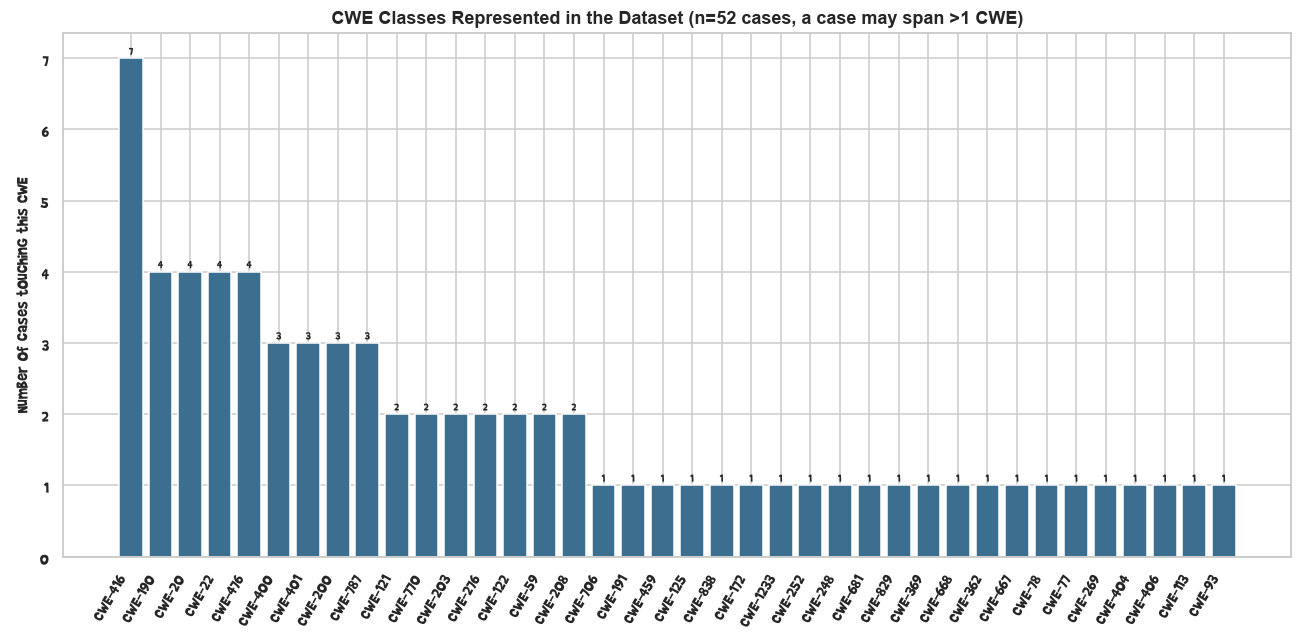

In [10]:
cwe_counts = pd.Series([c for lst in df["all_cwe_list"] for c in ("CWE-"+lst[0] for lst in [lst] if lst)]).value_counts() \
    if False else None
# (build cleanly instead of the one-liner above)
from collections import Counter
cwe_counter = Counter()
for lst in df["all_cwe_list"]:
    for c in lst:
        cwe_counter["CWE-" + c] += 1
cwe_counts = pd.Series(cwe_counter).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(cwe_counts.index, cwe_counts.values, color="#3B6E8F")
ax.set_ylabel("Number of cases touching this CWE")
ax.set_title(f"CWE Classes Represented in the Dataset (n={len(df)} cases, a case may span >1 CWE)")
ax.set_xticklabels(cwe_counts.index, rotation=60, ha="right")
for bar, v in zip(bars, cwe_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05, str(v), ha="center", fontsize=8)
savefig(fig, "04_cwe_distribution.png")
plt.show()

## 9. Subtype × CWE-family heatmap

saved: figures\05_subtype_by_cwe_heatmap.png


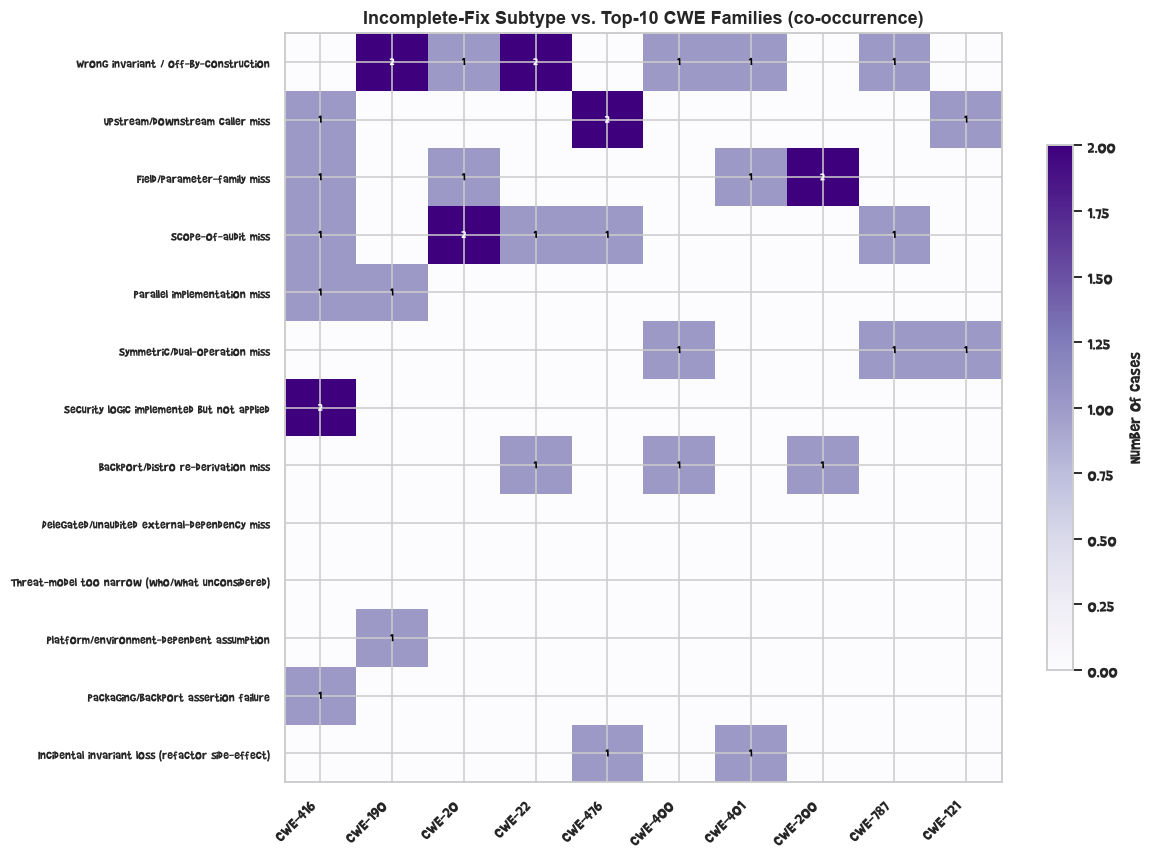

In [11]:
top_cwes = cwe_counts.head(10).index.tolist()
subtypes_sorted = subtype_counts.index.tolist()

mat = np.zeros((len(subtypes_sorted), len(top_cwes)))
for _, r in df.iterrows():
    si = subtypes_sorted.index(r["subtype"])
    for c in r["all_cwe_list"]:
        label = "CWE-" + c
        if label in top_cwes:
            mat[si, top_cwes.index(label)] += 1

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(mat, cmap="Purples", aspect="auto")
ax.set_xticks(range(len(top_cwes))); ax.set_xticklabels(top_cwes, rotation=45, ha="right")
ax.set_yticks(range(len(subtypes_sorted))); ax.set_yticklabels(subtypes_sorted, fontsize=8.5)
for i in range(len(subtypes_sorted)):
    for j in range(len(top_cwes)):
        if mat[i, j] > 0:
            ax.text(j, i, int(mat[i, j]), ha="center", va="center",
                    color="white" if mat[i, j] > mat.max()/2 else "black", fontsize=8)
ax.set_title("Incomplete-Fix Subtype vs. Top-10 CWE Families (co-occurrence)")
fig.colorbar(im, ax=ax, shrink=0.7, label="Number of cases")
savefig(fig, "05_subtype_by_cwe_heatmap.png")
plt.show()

## 10. CVSS severity: original vulnerability vs. its incomplete-fix bypass

`orig_cvss` has substantial missingness (many source reports don't restate the original CVE's CVSS) — bars are simply omitted where a score wasn't extractable, and this is called out rather than imputed.

saved: figures\06_severity_original_vs_incomplete.png


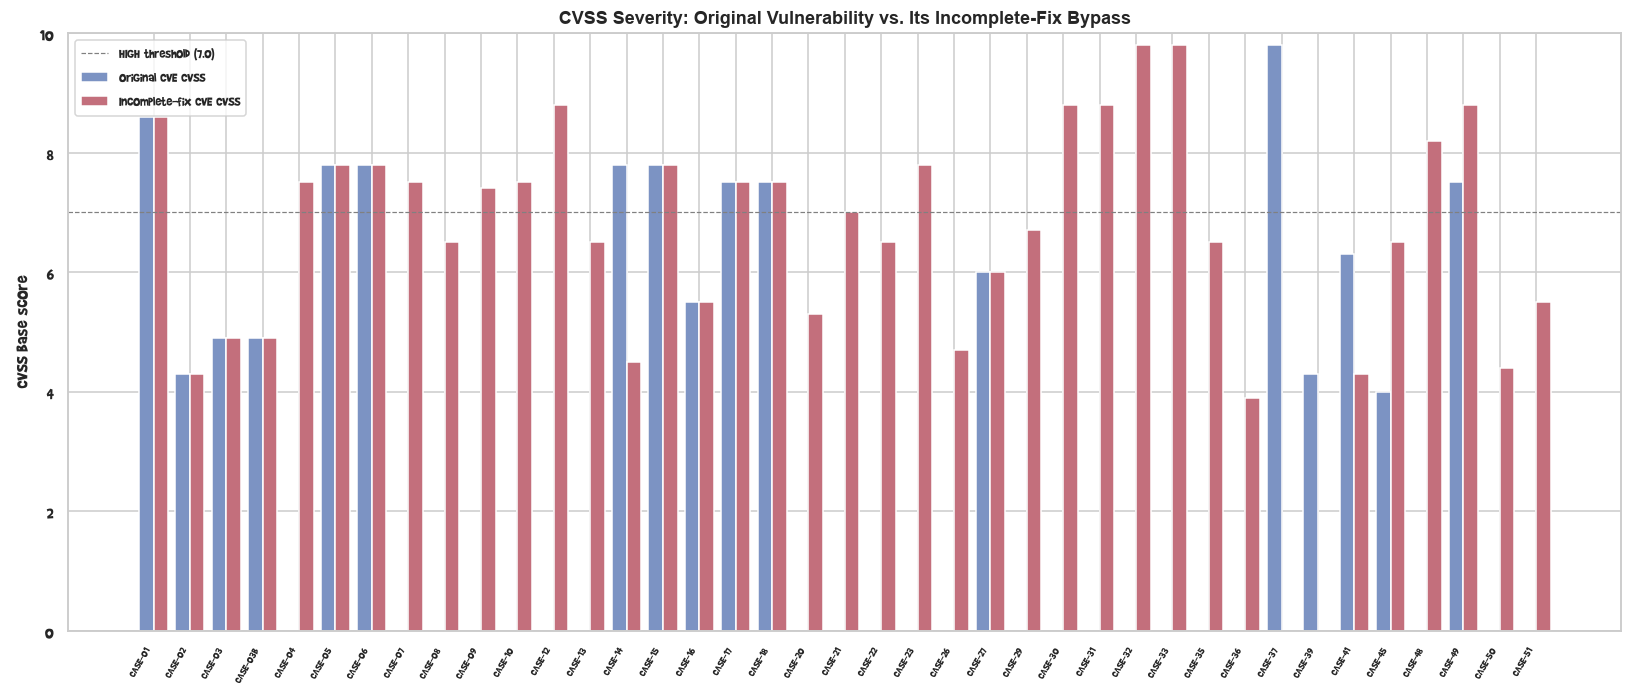

In [12]:
plot_df = df.dropna(subset=["orig_cvss", "incomplete_cvss"], how="all").copy()
x = np.arange(len(plot_df)); width = 0.4

fig, ax = plt.subplots(figsize=(15, 6.5))
ax.bar(x - width/2, plot_df["orig_cvss"], width, label="Original CVE CVSS", color="#7C93C3")
ax.bar(x + width/2, plot_df["incomplete_cvss"], width, label="Incomplete-fix CVE CVSS", color="#C36F7C")
ax.set_xticks(x); ax.set_xticklabels(plot_df["case_id"], rotation=60, ha="right", fontsize=7.5)
ax.set_ylabel("CVSS base score"); ax.set_ylim(0, 10)
ax.axhline(7.0, color="grey", ls="--", lw=0.8, label="HIGH threshold (7.0)")
ax.set_title("CVSS Severity: Original Vulnerability vs. Its Incomplete-Fix Bypass")
ax.legend(fontsize=9)
savefig(fig, "06_severity_original_vs_incomplete.png")
plt.show()

## 11. CVSS delta (incomplete-fix bypass − original)

Only computable where both scores are present. Positive = the bypass CVE was scored *more* severe than the original.

saved: figures\07_cvss_delta_hist.png


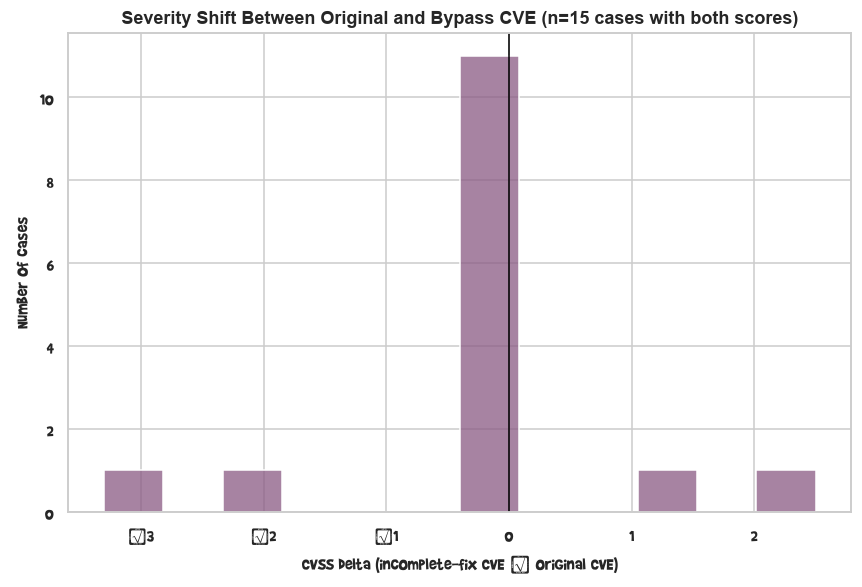

count    15.000000
mean     -0.100000
std       1.272792
min      -3.300000
25%       0.000000
50%       0.000000
75%       0.000000
max       2.500000
Name: cvss_delta, dtype: float64


In [13]:
delta = df["cvss_delta"].dropna()
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.histplot(delta, bins=12, kde=False, color="#8A5A83", ax=ax)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("CVSS delta (incomplete-fix CVE − original CVE)")
ax.set_ylabel("Number of cases")
ax.set_title(f"Severity Shift Between Original and Bypass CVE (n={len(delta)} cases with both scores)")
savefig(fig, "07_cvss_delta_hist.png")
plt.show()
print(delta.describe())

## 12. CVSS (incomplete-fix bypass) by subtype

saved: figures\08_cvss_by_subtype_box.png


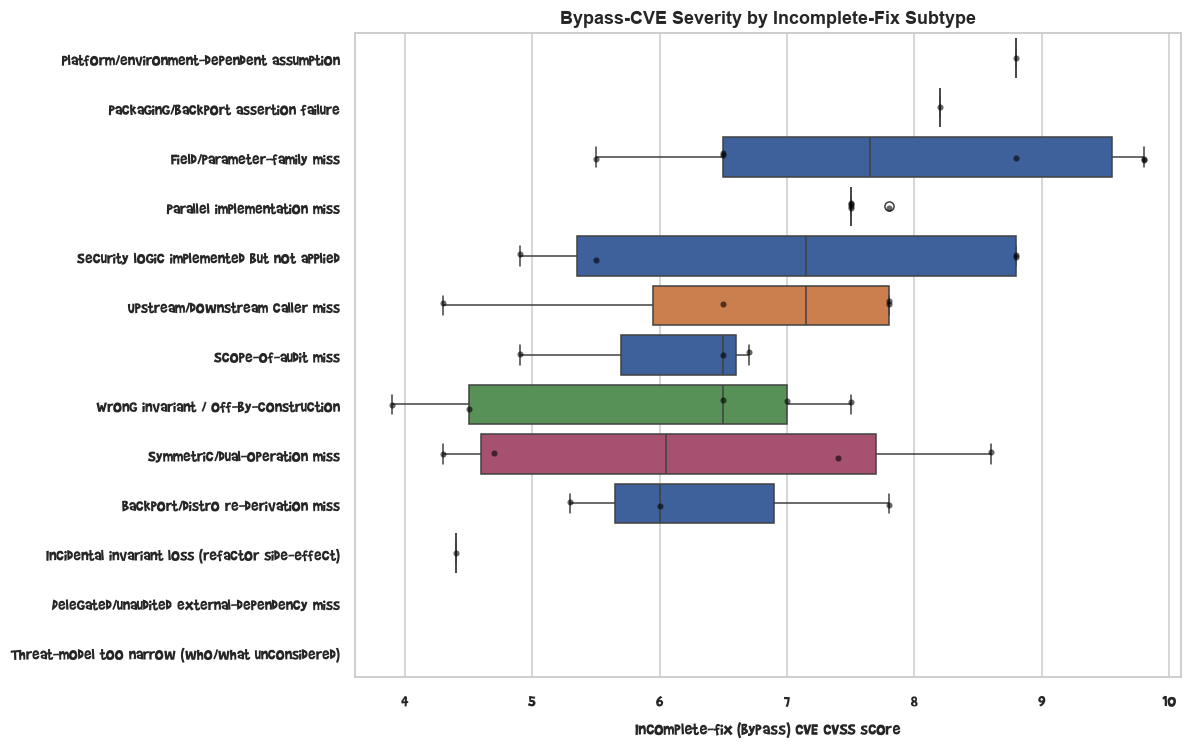

In [14]:
order = df.groupby("subtype")["incomplete_cvss"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(data=df, y="subtype", x="incomplete_cvss", order=order,
            palette=[PARENT_COLORS[SUBTYPE_PARENT[s]] for s in order], ax=ax)
sns.stripplot(data=df, y="subtype", x="incomplete_cvss", order=order, color="black", size=4, alpha=0.6, ax=ax)
ax.set_xlabel("Incomplete-fix (bypass) CVE CVSS score"); ax.set_ylabel("")
ax.set_title("Bypass-CVE Severity by Incomplete-Fix Subtype")
savefig(fig, "08_cvss_by_subtype_box.png")
plt.show()

## 13. Severity-word distribution (Critical/High/Medium/Low), original vs. bypass

saved: figures\09_severity_word_distribution.png


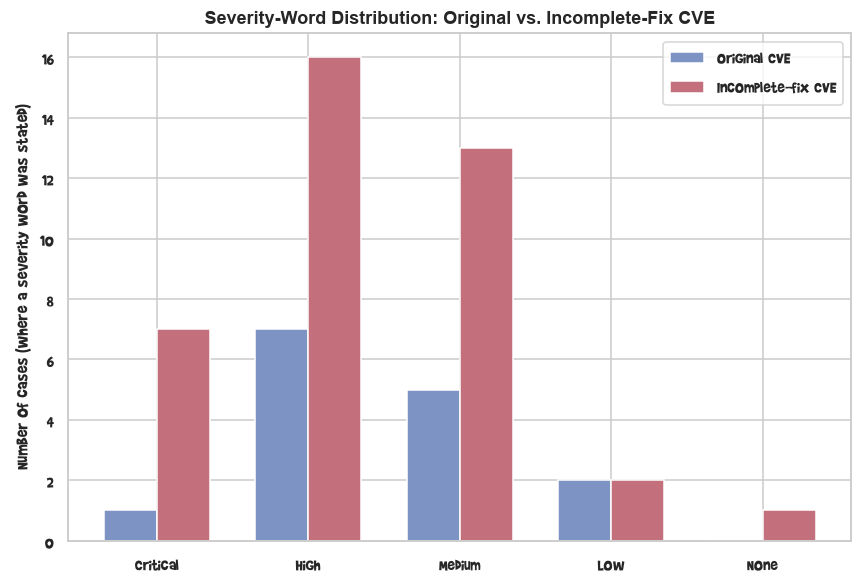

In [15]:
sev_order = ["Critical","High","Medium","Low","None"]
orig_sev = df["orig_severity_word"].value_counts().reindex(sev_order).fillna(0)
inc_sev = df["incomplete_severity_word"].value_counts().reindex(sev_order).fillna(0)

x = np.arange(len(sev_order)); width = 0.35
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(x - width/2, orig_sev.values, width, label="Original CVE", color="#7C93C3")
ax.bar(x + width/2, inc_sev.values, width, label="Incomplete-fix CVE", color="#C36F7C")
ax.set_xticks(x); ax.set_xticklabels(sev_order)
ax.set_ylabel("Number of cases (where a severity word was stated)")
ax.set_title("Severity-Word Distribution: Original vs. Incomplete-Fix CVE")
ax.legend()
savefig(fig, "09_severity_word_distribution.png")
plt.show()

## 14. Time elapsed between original fix and bypass discovery

saved: figures\10_gap_bucket_distribution.png


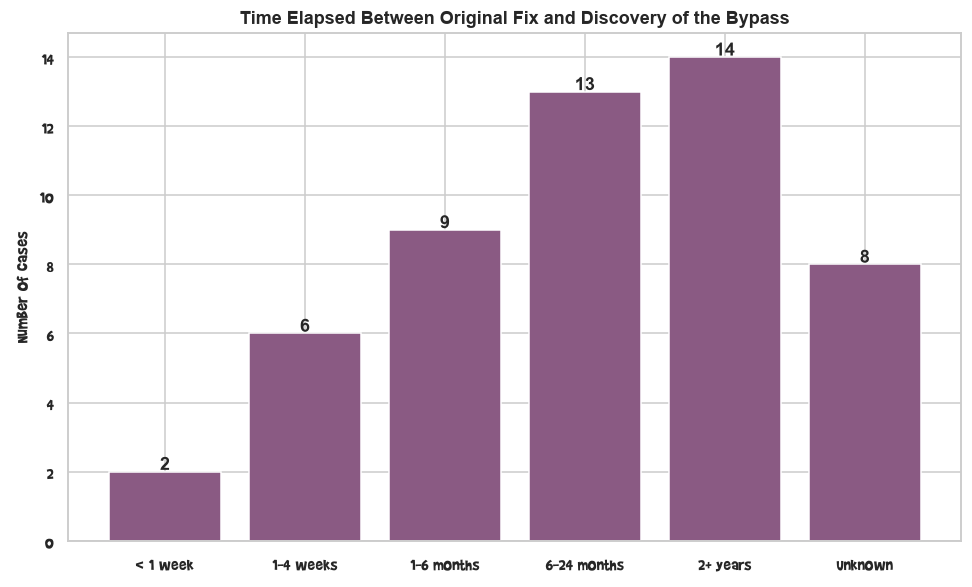

In [16]:
gap_order = ["< 1 week","1-4 weeks","1-6 months","6-24 months","2+ years","Unknown"]
gap_counts = df["gap_bucket"].value_counts().reindex(gap_order).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(gap_counts.index, gap_counts.values, color="#8A5A83")
ax.set_ylabel("Number of cases")
ax.set_title("Time Elapsed Between Original Fix and Discovery of the Bypass")
for bar, v in zip(bars, gap_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.05, str(int(v)), ha="center", fontweight="bold")
savefig(fig, "10_gap_bucket_distribution.png")
plt.show()

## 15. Gap-to-discovery (numeric days, log scale) by subtype

saved: figures\11_gap_days_by_subtype.png


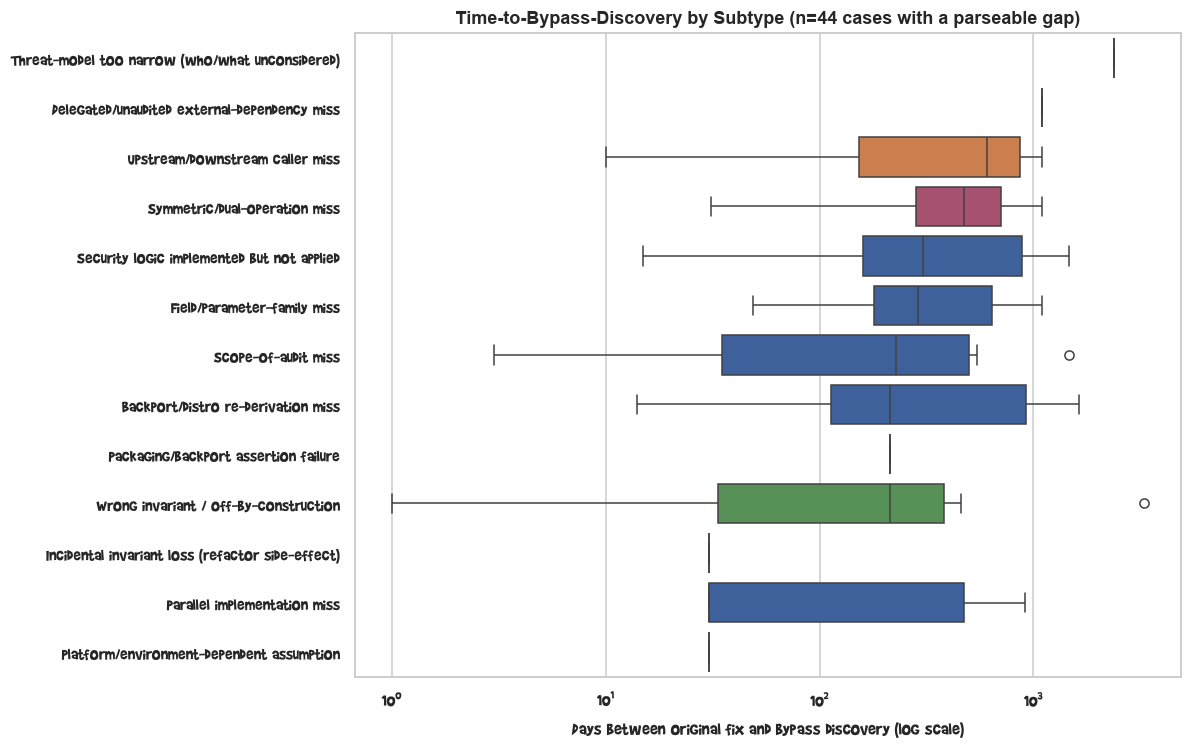

In [17]:
gd = df.dropna(subset=["gap_days"]).copy()
order2 = gd.groupby("subtype")["gap_days"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(data=gd, y="subtype", x="gap_days", order=order2,
            palette=[PARENT_COLORS[SUBTYPE_PARENT[s]] for s in order2], ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Days between original fix and bypass discovery (log scale)"); ax.set_ylabel("")
ax.set_title(f"Time-to-Bypass-Discovery by Subtype (n={len(gd)} cases with a parseable gap)")
savefig(fig, "11_gap_days_by_subtype.png")
plt.show()

## 16. Ecosystem / domain distribution

saved: figures\12_ecosystem_distribution.png


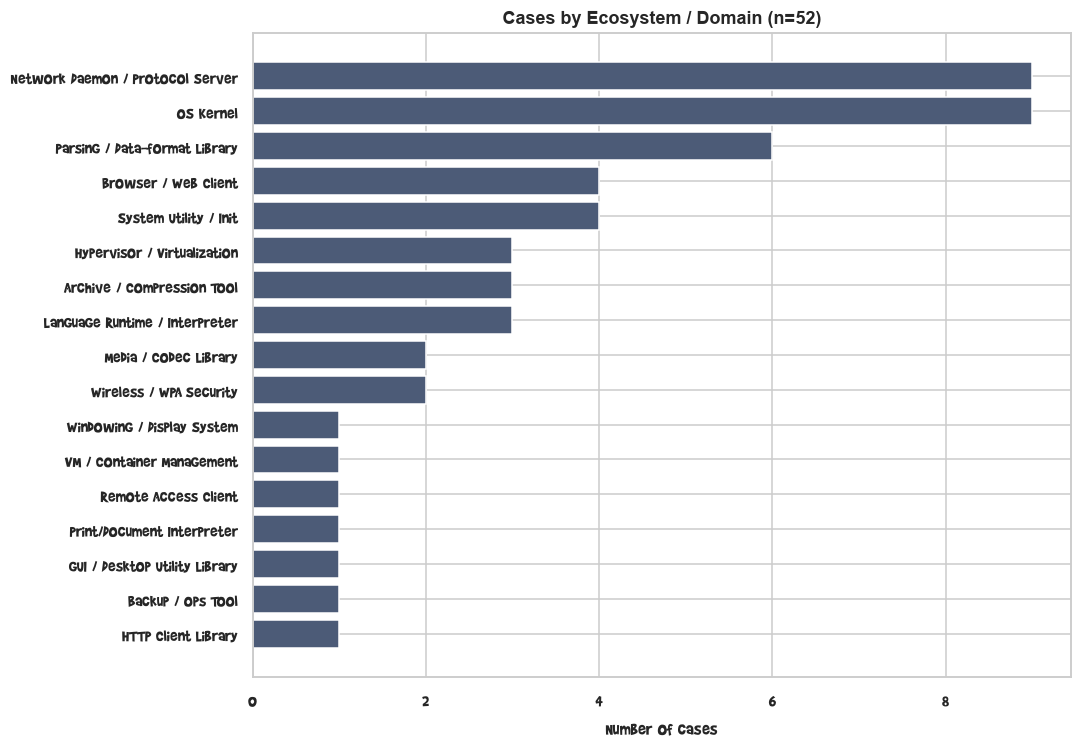

saved: figures\13_ecosystem_tier_pie.png


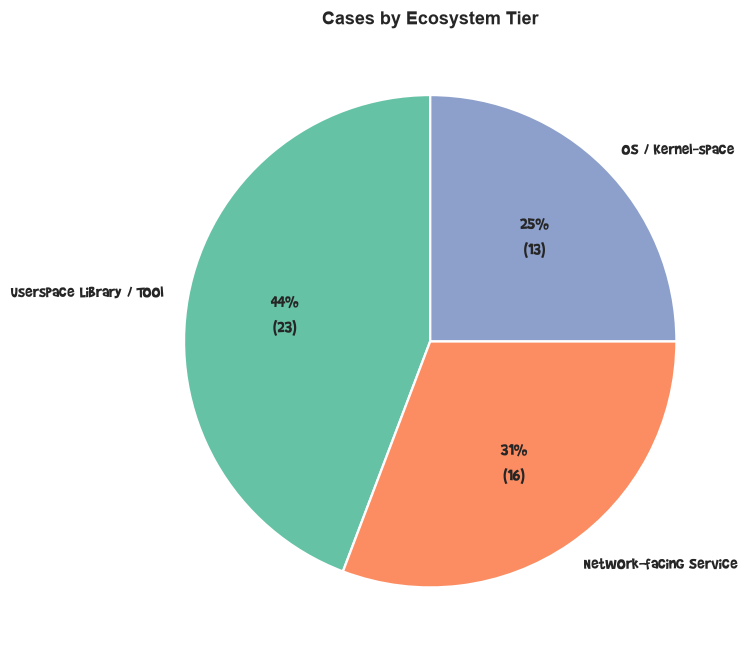

In [18]:
eco_counts = df["ecosystem"].value_counts()
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(eco_counts.index[::-1], eco_counts.values[::-1], color="#4C5B77")
ax.set_xlabel("Number of cases")
ax.set_title(f"Cases by Ecosystem / Domain (n={len(df)})")
savefig(fig, "12_ecosystem_distribution.png")
plt.show()

tier_counts = df["ecosystem_tier"].value_counts()
fig, ax = plt.subplots(figsize=(7,7))
ax.pie(tier_counts.values, labels=tier_counts.index, autopct=lambda p: f"{p:.0f}%\n({round(p*tier_counts.sum()/100)})",
       colors=sns.color_palette("Set2", len(tier_counts)), startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5))
ax.set_title("Cases by Ecosystem Tier")
savefig(fig, "13_ecosystem_tier_pie.png")
plt.show()

## 17. Subtype × ecosystem tier heatmap

saved: figures\14_subtype_by_ecosystem_tier_heatmap.png


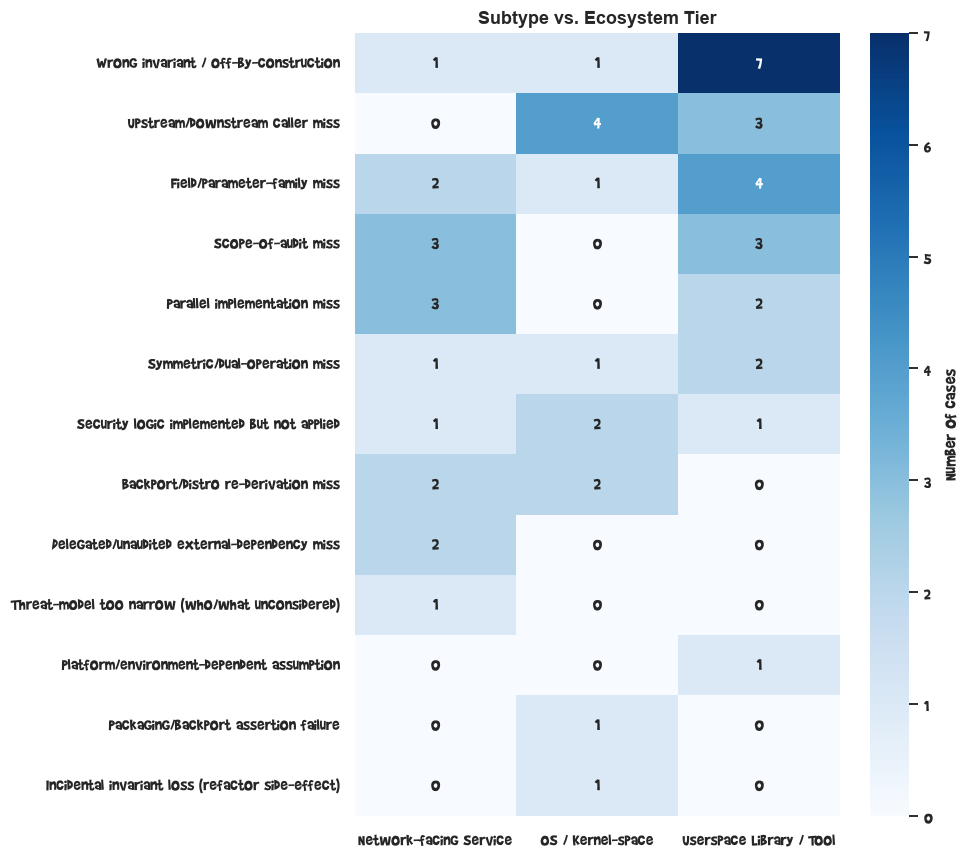

In [19]:
ct = pd.crosstab(df["subtype"], df["ecosystem_tier"]).reindex(subtype_counts.index)
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar_kws={"label":"Number of cases"}, ax=ax)
ax.set_title("Subtype vs. Ecosystem Tier")
ax.set_xlabel(""); ax.set_ylabel("")
savefig(fig, "14_subtype_by_ecosystem_tier_heatmap.png")
plt.show()

## 18. Language distribution

saved: figures\15_language_distribution.png


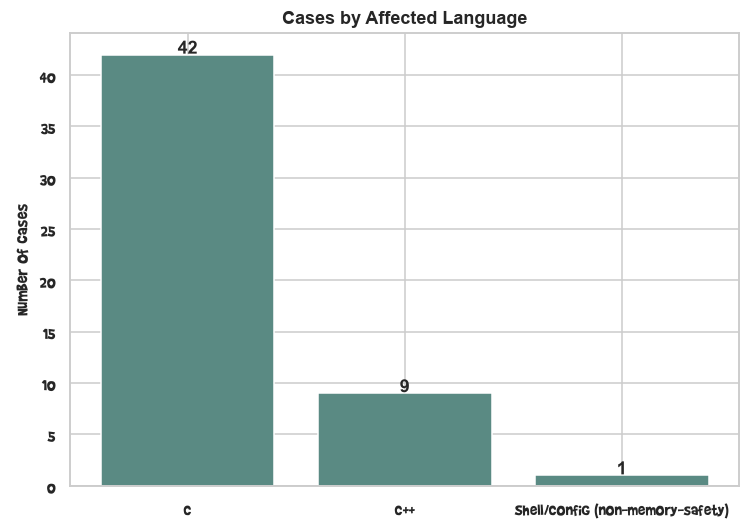

In [20]:
lang_counts = df["language_norm"].value_counts()
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(lang_counts.index, lang_counts.values, color="#5A8A83")
ax.set_ylabel("Number of cases")
ax.set_title("Cases by Affected Language")
for i, v in enumerate(lang_counts.values):
    ax.text(i, v+0.1, str(v), ha="center", fontweight="bold")
savefig(fig, "15_language_distribution.png")
plt.show()

## 19. Number of distinct CVE IDs in lineage / lineage stage count

saved: figures\16_lineage_length_distributions.png


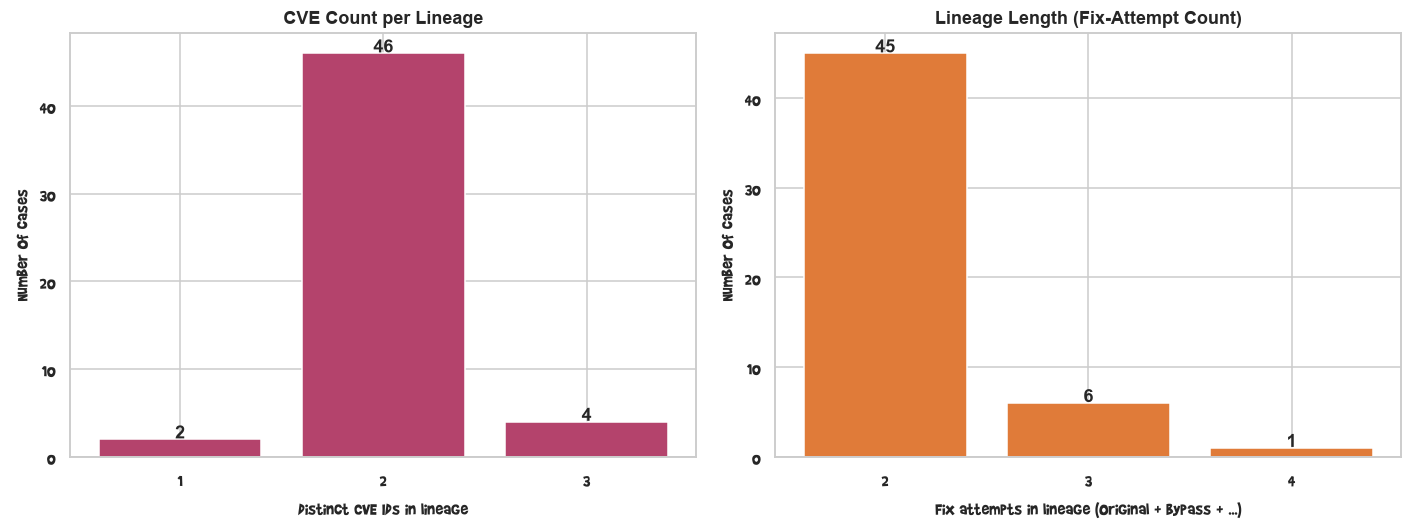

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
n_counts = df["n_cves_in_lineage"].value_counts().sort_index()
axes[0].bar(n_counts.index.astype(str), n_counts.values, color="#B4436C")
axes[0].set_xlabel("Distinct CVE IDs in lineage"); axes[0].set_ylabel("Number of cases")
axes[0].set_title("CVE Count per Lineage")
for i, v in enumerate(n_counts.values):
    axes[0].text(i, v+0.1, str(v), ha="center", fontweight="bold")

stage_counts = df["lineage_stage_count"].value_counts().sort_index()
axes[1].bar(stage_counts.index.astype(str), stage_counts.values, color="#E07B39")
axes[1].set_xlabel("Fix attempts in lineage (original + bypass + ...)"); axes[1].set_ylabel("Number of cases")
axes[1].set_title("Lineage Length (Fix-Attempt Count)")
for i, v in enumerate(stage_counts.values):
    axes[1].text(i, v+0.1, str(v), ha="center", fontweight="bold")
savefig(fig, "16_lineage_length_distributions.png")
plt.show()

## 20. Discoverer type

saved: figures\17_discoverer_type_distribution.png


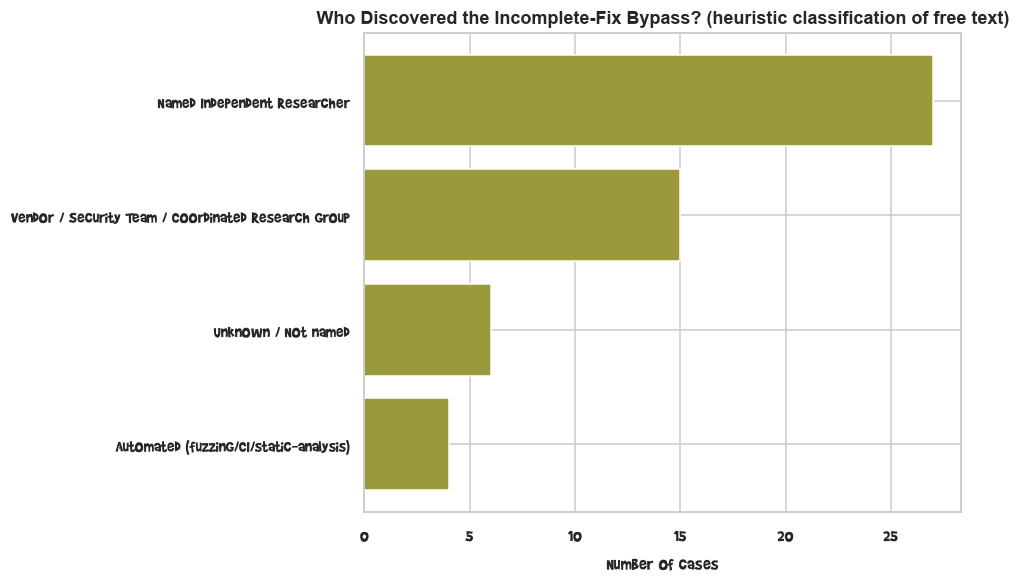

In [22]:
disc_counts = df["discoverer_type"].value_counts()
fig, ax = plt.subplots(figsize=(9,5.5))
ax.barh(disc_counts.index[::-1], disc_counts.values[::-1], color="#9A9A3D")
ax.set_xlabel("Number of cases")
ax.set_title("Who Discovered the Incomplete-Fix Bypass? (heuristic classification of free text)")
savefig(fig, "17_discoverer_type_distribution.png")
plt.show()

## 21. Discoverer type × subtype

saved: figures\18_subtype_by_discoverer_heatmap.png


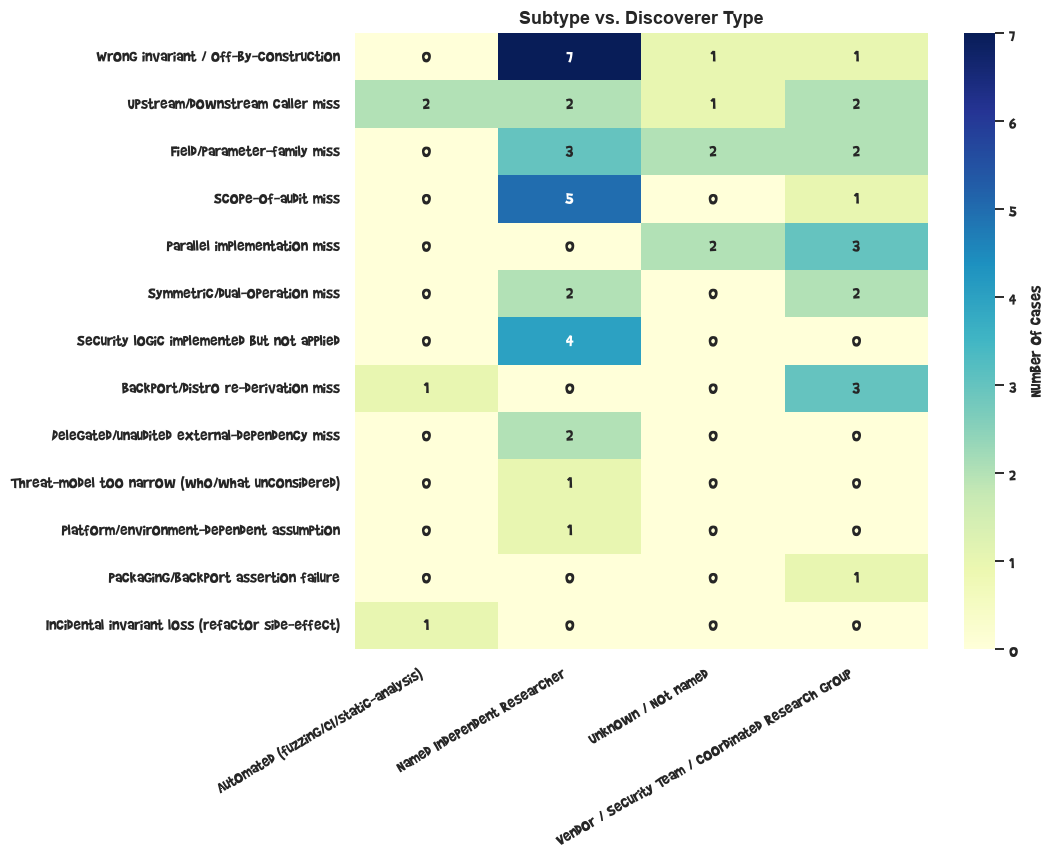

In [23]:
ct2 = pd.crosstab(df["subtype"], df["discoverer_type"]).reindex(subtype_counts.index)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ct2, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label":"Number of cases"}, ax=ax)
ax.set_title("Subtype vs. Discoverer Type")
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
savefig(fig, "18_subtype_by_discoverer_heatmap.png")
plt.show()

## 22. Timeline: original-fix year vs. bypass-discovery year

saved: figures\19_timeline_scatter.png


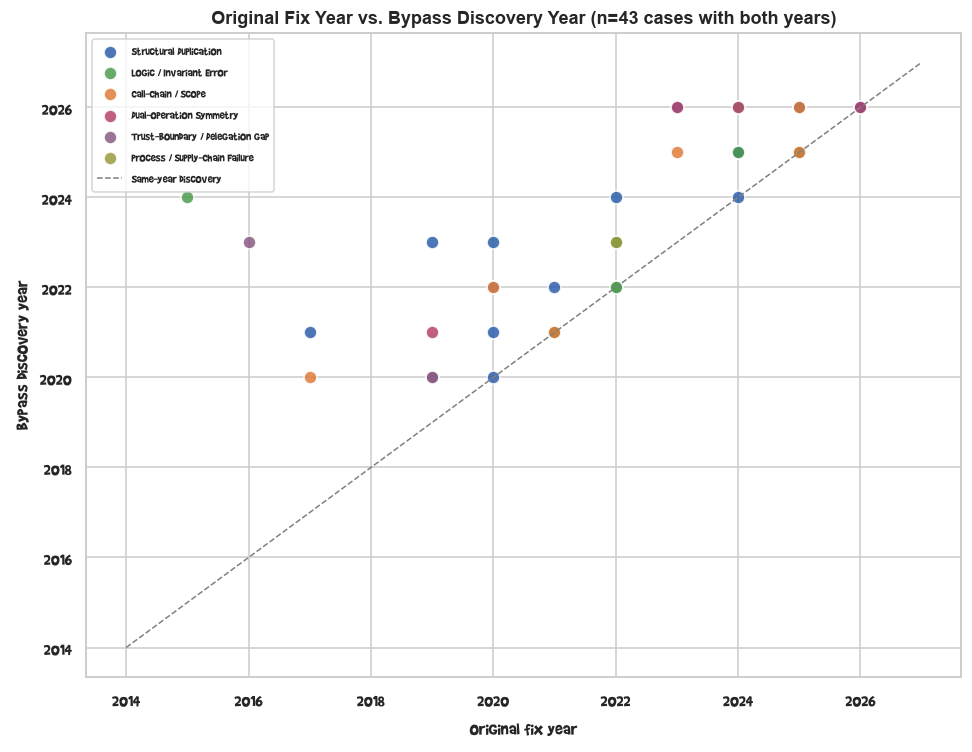

In [24]:
td = df.dropna(subset=["orig_fix_year", "bypass_year"]).copy()
fig, ax = plt.subplots(figsize=(9, 7))
for g in PARENT_GROUP_ORDER:
    sub = td[td.parent_group == g]
    ax.scatter(sub["orig_fix_year"], sub["bypass_year"], label=g, color=PARENT_COLORS[g], s=70, alpha=0.85, edgecolor="white")
lims = [td["orig_fix_year"].min()-1, td["bypass_year"].max()+1]
ax.plot(lims, lims, "--", color="grey", lw=1, label="Same-year discovery")
ax.set_xlabel("Original fix year"); ax.set_ylabel("Bypass discovery year")
ax.set_title(f"Original Fix Year vs. Bypass Discovery Year (n={len(td)} cases with both years)")
ax.legend(fontsize=8, loc="upper left")
savefig(fig, "19_timeline_scatter.png")
plt.show()

## 23. Cases per product/component (top 15) & resolved vs. unresolved lineages

saved: figures\20_top_products_and_resolution_status.png


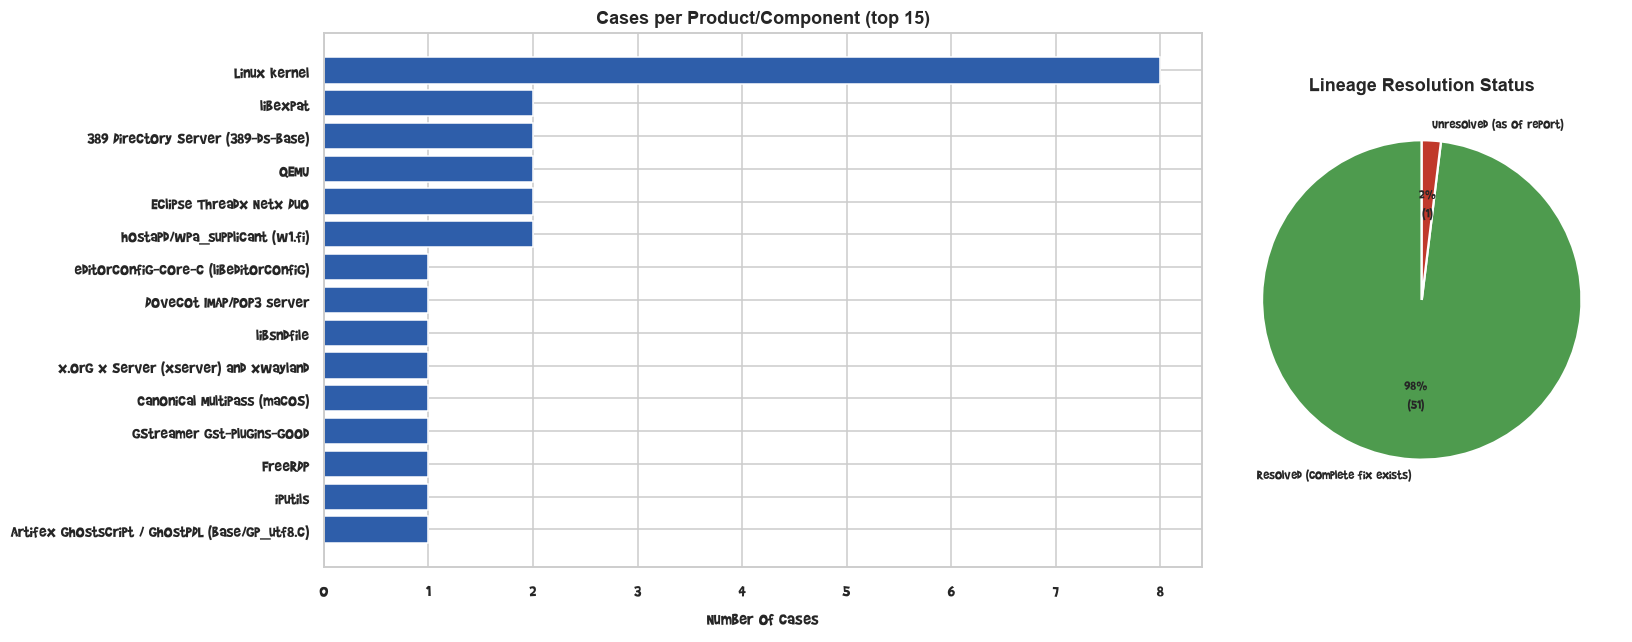

In [25]:
# top products -- use a shortened label (text before the em-dash / double-hyphen)
def short_product(s):
    for sep in [" \u2014 ", " -- "]:
        if sep in s:
            return s.split(sep)[0].strip()
    return s[:40]

df["product_short"] = df["product_component"].map(short_product)
top_products = df["product_short"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios":[2.2,1]})
axes[0].barh(top_products.index[::-1], top_products.values[::-1], color="#2E5EAA")
axes[0].set_xlabel("Number of cases"); axes[0].set_title("Cases per Product/Component (top 15)")

resolved_counts = df["is_unresolved"].value_counts().rename({False:"Resolved (complete fix exists)", True:"Unresolved (as of report)"})
axes[1].pie(resolved_counts.values, labels=resolved_counts.index, autopct=lambda p: f"{p:.0f}%\n({round(p*resolved_counts.sum()/100)})",
            colors=["#4E9B4E","#C0392B"], startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5), textprops=dict(fontsize=9))
axes[1].set_title("Lineage Resolution Status")
savefig(fig, "20_top_products_and_resolution_status.png")
plt.show()

## 24. Summary statistics export

In [26]:
summary_path = os.path.join(OUTDIR, "..", "summary_stats.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    n = len(df)
    f.write("INCOMPLETE-FIX CASE SET (51 cases / 52 rows) -- SUMMARY STATISTICS\n")
    f.write("="*70 + "\n")
    f.write(f"Total rows analyzed: {n}\n\n")

    f.write("Subtype distribution:\n")
    for s, c in subtype_counts.items():
        f.write(f"  {s:<52s} {c:>2d}  ({100*c/n:4.1f}%)\n")
    f.write("\nParent-group distribution:\n")
    for g, c in parent_counts.items():
        f.write(f"  {g:<34s} {c:>2d}  ({100*c/n:4.1f}%)\n")
    f.write("\nCWE frequency (case may touch >1 CWE):\n")
    for c, v in cwe_counts.items():
        f.write(f"  {c:<10s} {v:>2d}\n")
    f.write("\nGap-to-discovery buckets:\n")
    for g, v in gap_counts.items():
        f.write(f"  {g:<14s} {int(v):>2d}\n")
    f.write("\nEcosystem split:\n")
    for e, v in eco_counts.items():
        f.write(f"  {e:<34s} {v:>2d}\n")
    f.write("\nLanguage split:\n")
    for l, v in lang_counts.items():
        f.write(f"  {l:<34s} {v:>2d}\n")
    f.write("\nDiscoverer type split:\n")
    for d, v in disc_counts.items():
        f.write(f"  {d:<52s} {v:>2d}\n")
    f.write(f"\nUnresolved lineages: {int(df['is_unresolved'].sum())} / {n}\n")
    f.write(f"CVSS delta (bypass - original), n={delta.shape[0]}: mean={delta.mean():.2f}, median={delta.median():.2f}\n")

print(f"Summary written to {summary_path}")

enriched_path = os.path.join(OUTDIR, "..", "incomplete_fixes_enriched.csv")
df.drop(columns=["orig_cwe_list","incomplete_cwe_list","all_cwe_list"]).to_csv(enriched_path, index=False)
print(f"Enriched dataframe written to {enriched_path}")

Summary written to figures\..\summary_stats.txt
Enriched dataframe written to figures\..\incomplete_fixes_enriched.csv


## 25. Takeaways

- **Structural Duplication is the dominant parent category** (fix applied at
  fewer than the N structurally-similar sites that needed it) — confirmed
  across the expanded 51-case set, not just the original 18.
- The two next-largest groups, **Logic/Invariant Error** and
  **Call-Chain/Scope**, describe genuinely different failure modes (a
  miscalibrated check vs. a check in the wrong function) and should not be
  merged into Structural Duplication even though all three often *look*
  similar at the CWE level.
- Two small but conceptually important groups — **Trust-Boundary/Delegation
  Gap** and **Process/Supply-Chain Failure** — only became visible once the
  dataset grew past 18 cases; they are rare (3 and 1 cases respectively) but
  represent qualitatively distinct failure mechanisms that a subtype
  classifier would need dedicated examples of.
- See the companion notebook, `incomplete_fixes_correlation_bias_ml_feasibility.ipynb`,
  for statistical correlation/bias testing and a discussion of whether this
  dataset can support training a subtype- or presence-detection model.